<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/PCA_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!

Dataset Shape:
(1143, 13)

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  qua

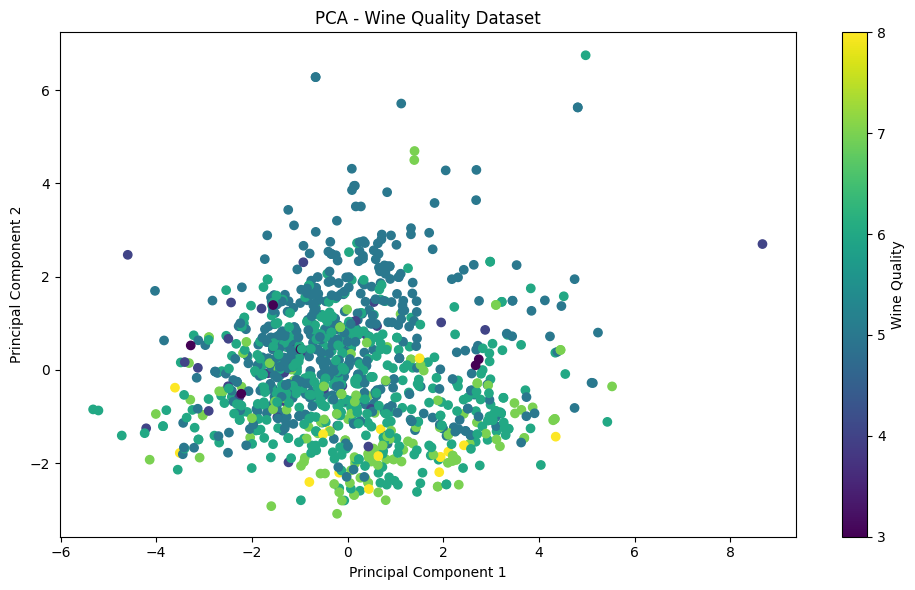

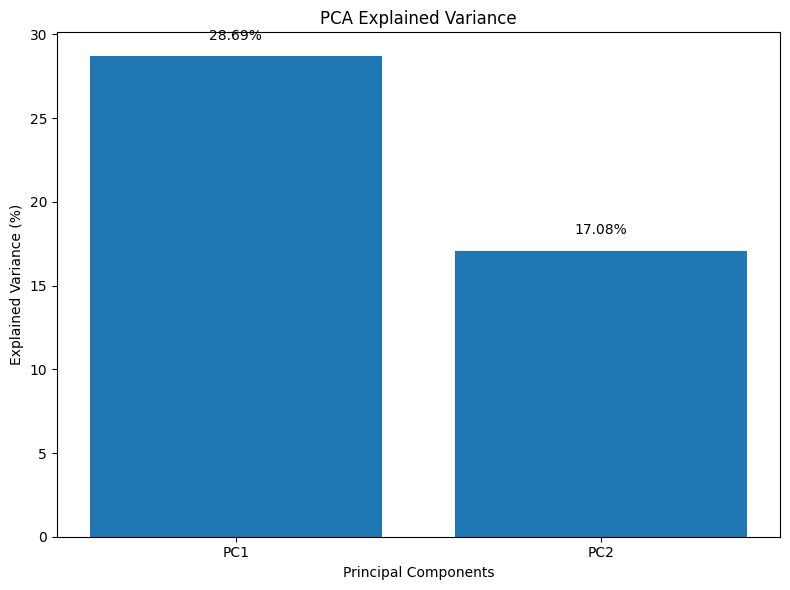

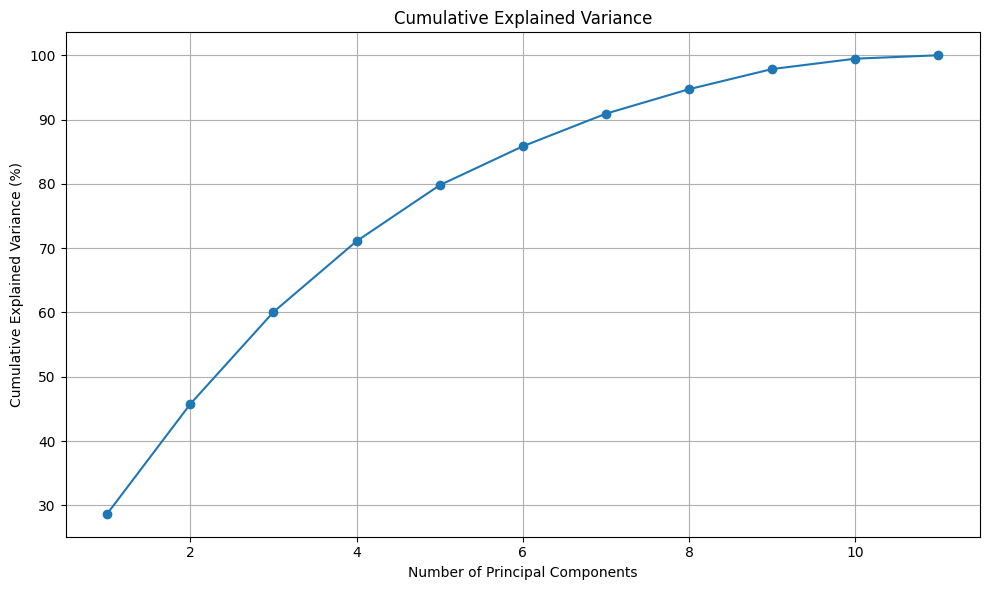



PCA FINAL SUMMARY
Original Number of Features: 11
Reduced Number of Features: 2
PC1 Variance: 28.69 %
PC2 Variance: 17.08 %
Total Variance Preserved: 45.77 %


In [1]:
# ============================================================
# PCA - WINE QUALITY DATASET
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("WineQT.csv")

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. SELECT NUMERICAL FEATURES
# ============================================================

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

X = df[features]

# Target only for visualization
y = df["quality"]


# ============================================================
# 4. STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 5. APPLY PCA
# ============================================================

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)


# ============================================================
# 6. EXPLAINED VARIANCE
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_
)

print("\nExplained Variance Ratio:")

print(
    explained_variance
)

total_variance = (
    explained_variance.sum() * 100
)

print(
    "\nTotal Explained Variance:",
    round(total_variance, 2),
    "%"
)


# ============================================================
# 7. CREATE PCA DATAFRAME
# ============================================================

pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)

pca_df["Quality"] = y.values


print("\nPCA Data:")
print(
    pca_df.head()
)


# ============================================================
# 8. GRAPH 1 - PCA SCATTER PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["Quality"]
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA - Wine Quality Dataset"
)

plt.colorbar(
    label="Wine Quality"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. GRAPH 2 - EXPLAINED VARIANCE
# ============================================================

components = [
    "PC1",
    "PC2"
]

variance_percentage = (
    explained_variance * 100
)

plt.figure(
    figsize=(8, 6)
)

plt.bar(
    components,
    variance_percentage
)

plt.xlabel(
    "Principal Components"
)

plt.ylabel(
    "Explained Variance (%)"
)

plt.title(
    "PCA Explained Variance"
)

for i, value in enumerate(
    variance_percentage
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 10. PCA WITH ALL COMPONENTS
# ============================================================

pca_all = PCA()

X_pca_all = pca_all.fit_transform(
    X_scaled
)

cumulative_variance = np.cumsum(
    pca_all.explained_variance_ratio_
)


# ============================================================
# 11. GRAPH 3 - CUMULATIVE VARIANCE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)

print(
    "PCA FINAL SUMMARY"
)

print("=" * 60)

print(
    "Original Number of Features:",
    X.shape[1]
)

print(
    "Reduced Number of Features:",
    X_pca.shape[1]
)

print(
    "PC1 Variance:",
    round(
        explained_variance[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2 Variance:",
    round(
        explained_variance[1] * 100,
        2
    ),
    "%"
)

print(
    "Total Variance Preserved:",
    round(
        total_variance,
        2
    ),
    "%"
)